In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/test-file/tested.csv


In [2]:
df=pd.read_csv('/kaggle/input/test-file/tested.csv')
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [3]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
import warnings
warnings.filterwarnings("ignore")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
df.describe(include='O')

,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Kelly, Mr. James",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [10]:
df[df['Age'].isnull()]
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [11]:
df['Age'].mean()

30.272590361445783

In [12]:
df['Age'] = df['Age'].fillna(30.27)

In [13]:
df['Cabin'].mode()[0]


'B57 B59 B63 B66'

In [14]:
df['Cabin']=df['Cabin'].fillna('B57')

In [15]:
df.drop('Cabin',axis=1,inplace=True)

In [16]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.50,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,30.27,0,0,359309,8.0500,S


In [17]:
df['FamilySize']=df['SibSp']+df['Parch'] + 1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,892,0,3,"Kelly, Mr. James",male,34.50,0,0,330911,7.8292,Q,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00,1,0,363272,7.0000,S,2
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,Q,1
3,895,0,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,S,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00,1,1,3101298,12.2875,S,3
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27,0,0,A.5. 3236,8.0500,S,1
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00,0,0,PC 17758,108.9000,C,1
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50,0,0,SOTON/O.Q. 3101262,7.2500,S,1
416,1308,0,3,"Ware, Mr. Frederick",male,30.27,0,0,359309,8.0500,S,1


In [18]:
df['IsAlone']=(df['FamilySize']==1).astype(int)
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,892,0,3,"Kelly, Mr. James",male,34.50,0,0,330911,7.8292,Q,1,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00,1,0,363272,7.0000,S,2,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,Q,1,1
3,895,0,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,S,1,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00,1,1,3101298,12.2875,S,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27,0,0,A.5. 3236,8.0500,S,1,1
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00,0,0,PC 17758,108.9000,C,1,1
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50,0,0,SOTON/O.Q. 3101262,7.2500,S,1,1
416,1308,0,3,"Ware, Mr. Frederick",male,30.27,0,0,359309,8.0500,S,1,1


In [19]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64

In [20]:
df['Fare'] = df['Fare'].fillna(35.627)

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64

In [22]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,892,0,3,"Kelly, Mr. James",male,34.50,0,0,330911,7.8292,Q,1,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00,1,0,363272,7.0000,S,2,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,Q,1,1
3,895,0,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,S,1,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00,1,1,3101298,12.2875,S,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27,0,0,A.5. 3236,8.0500,S,1,1
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00,0,0,PC 17758,108.9000,C,1,1
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50,0,0,SOTON/O.Q. 3101262,7.2500,S,1,1
416,1308,0,3,"Ware, Mr. Frederick",male,30.27,0,0,359309,8.0500,S,1,1


In [23]:
surivial_rates=df.groupby('Sex')['Survived'].mean()
print(surivial_rates)

Sex
female    1.0
male      0.0
Name: Survived, dtype: float64


In [24]:
survived_by_class=df.groupby('Pclass')['Survived'].mean()
print(survived_by_class)

Pclass
1    0.467290
2    0.322581
3    0.330275
Name: Survived, dtype: float64


In [25]:
Embarkation_survived=df.groupby('Embarked')['Survived'].mean()
print(Embarkation_survived)

Embarked
C    0.392157
Q    0.521739
S    0.325926
Name: Survived, dtype: float64


In [26]:
Family_survived=df.groupby('FamilySize')['Survived'].mean()
print(Family_survived)

FamilySize
1     0.268775
2     0.486486
3     0.526316
4     0.714286
5     0.285714
6     0.666667
7     0.250000
8     0.500000
11    0.500000
Name: Survived, dtype: float64


In [27]:
Fare_survived=df.groupby('Fare')['Survived'].mean()
print(Fare_survived)


Fare
0.0000      0.0
3.1708      0.0
6.4375      0.0
6.4958      0.0
6.9500      1.0
           ... 
227.5250    0.0
247.5208    1.0
262.3750    0.6
263.0000    1.0
512.3292    1.0
Name: Survived, Length: 170, dtype: float64


In [28]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

pio.renderers.default = 'iframe_connected'

In [29]:
surivial_rates=df.groupby('Sex')['Survived'].mean().reset_index()
gender_fig=px.bar(surivial_rates,x='Sex',y='Survived')
gender_fig.update_layout(title='survival by gender')
gender_fig.show()

In [30]:
pclass_survival = df.groupby('Pclass')['Survived'].mean().reset_index()
Pclass_fig=px.bar(pclass_survival,x='Pclass',y='Survived',title='Survival by class')
Pclass_fig.show()

In [31]:
embarked_survival=df.groupby('Embarked')['Survived'].mean().reset_index()
embarked_fig=px.bar(embarked_survival,x='Embarked',y='Survived',title='Embarked figure')
embarked_fig.show()

In [32]:
fig_fare = px.histogram(df, x='Fare',color='Survived',barmode='overlay',title='fare distribution by survived')
fig_fare.show()

In [33]:
fig_Age=px.histogram(df,x='Age',color='Survived',barmode='overlay',title='Age distribution by survived')
fig_Age.show()

In [34]:
age_box_plot=px.box(df,x='Survived',y='Age',color='Survived',title='Age distribution by survival')
age_box_plot.show()

In [35]:
fare_box_plot=px.box(df,x='Survived',y='Fare',color='Survived',title='Fare distribution by survival')
fare_box_plot.show()

In [36]:
import plotly.figure_factory as ff
correlation=df.corr(numeric_only=True)
fig_corr=ff.create_annotated_heatmap(x=correlation.columns.tolist(),y=correlation.index.tolist(),z=correlation.values,showscale=True, annotation_text=correlation.round(2).values)
fig_corr.show()


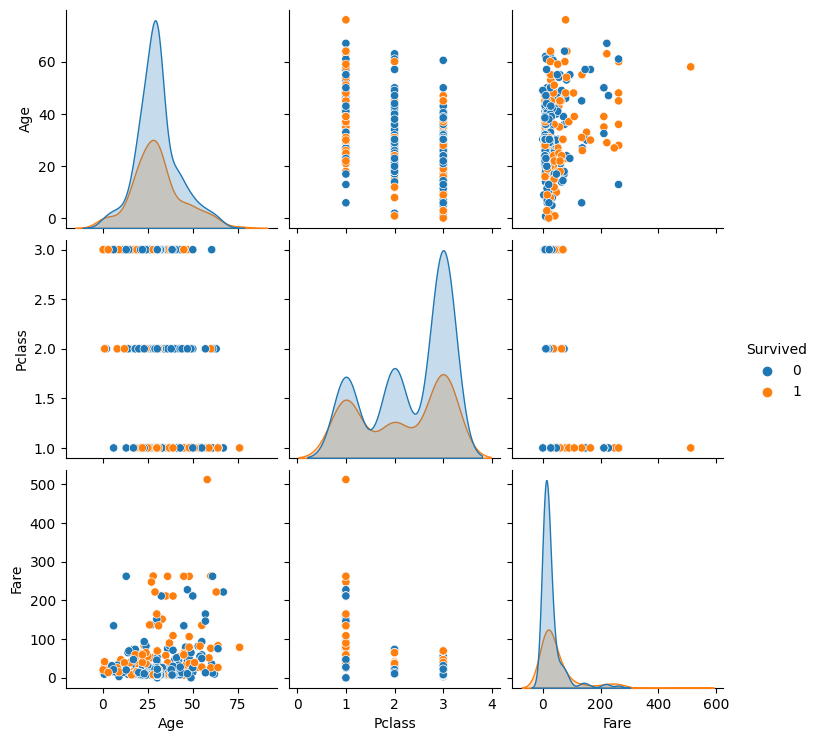

In [37]:
sns.pairplot(df,vars=['Age','Pclass','Fare'],hue='Survived')

In [38]:
fig_scatter=px.scatter(df,x='Age',y='Fare',color='Survived',title='Age and Fare colored by survived' ,hover_data=['Sex', 'Pclass', 'Embarked'])
fig_scatter.show()

In [39]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,892,0,3,"Kelly, Mr. James",male,34.50,0,0,330911,7.8292,Q,1,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00,1,0,363272,7.0000,S,2,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,Q,1,1
3,895,0,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,S,1,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00,1,1,3101298,12.2875,S,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27,0,0,A.5. 3236,8.0500,S,1,1
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00,0,0,PC 17758,108.9000,C,1,1
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50,0,0,SOTON/O.Q. 3101262,7.2500,S,1,1
416,1308,0,3,"Ware, Mr. Frederick",male,30.27,0,0,359309,8.0500,S,1,1


In [40]:
df.to_excel("Titanic.xlsx",index=False)